In [3]:
#loading and preprocessing a healthcare dataset for regression analysis
# This script loads a healthcare dataset, preprocesses it, and prepares it for regression analysis.
# how the 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load stroke dataset
import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
# Drop missing rows
df = df.dropna()

# Encode categorical variables
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
df[categorical_cols] = df[categorical_cols].apply(LabelEncoder().fit_transform)

# Features and target
X = df[["age", "hypertension", "heart_disease", "bmi", "work_type", 
        "gender", "ever_married", "Residence_type", "smoking_status"]]
y = df["avg_glucose_level"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



MSE: 1924.1870462786837
R²: 0.0314128656923387


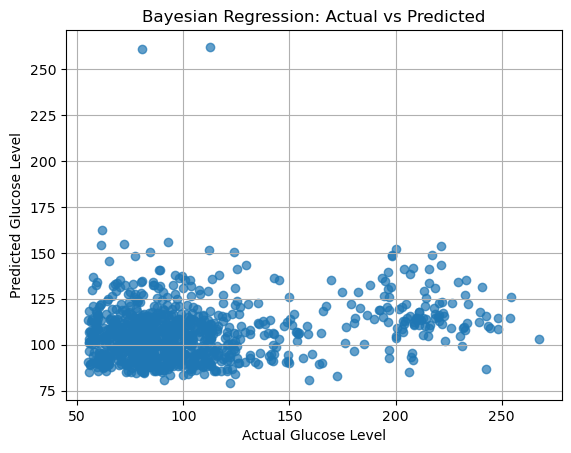

In [4]:
# Fitting Bayesian regression model
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Train model
model = BayesianRidge()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Visualize prediction vs actual
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Glucose Level")
plt.ylabel("Predicted Glucose Level")
plt.title("Bayesian Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


Linear Regression MSE: 1928.310724259804
R²: 0.02933711040323339


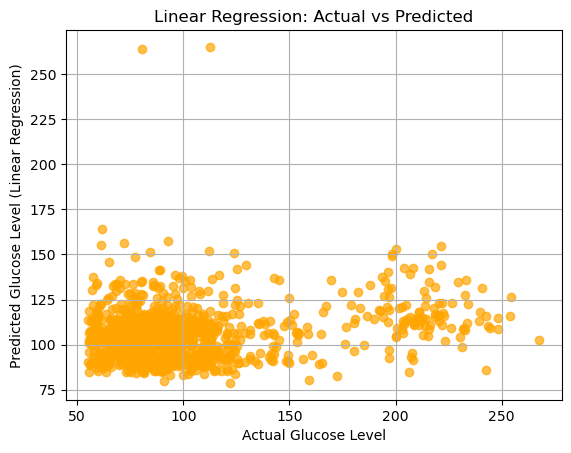

Decision Tree MSE: 3559.582633706721
R²: -0.7918039460774771


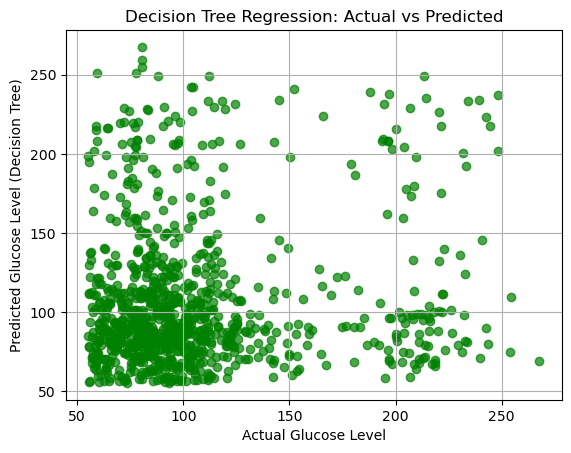

In [18]:
#comparing with linear regression
from sklearn.linear_model import LinearRegression   
# Train linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
# Predict and evaluate4     
y_pred_linear = linear_model.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_linear))
print("R²:", r2_score(y_test, y_pred_linear))

# Visualize linear regression prediction vs actual
plt.scatter(y_test, y_pred_linear, alpha=0.7, color='orange')
plt.xlabel("Actual Glucose Level")
plt.ylabel("Predicted Glucose Level (Linear Regression)")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

#comparing with decision tree regression
from sklearn.tree import DecisionTreeRegressor
# Train decision tree regression model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
# Predict and evaluate
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_tree))
print("R²:", r2_score(y_test, y_pred_tree))
# Visualize decision tree regression prediction vs actual
plt.scatter(y_test, y_pred_tree, alpha=0.7, color='green')
plt.xlabel("Actual Glucose Level")
plt.ylabel("Predicted Glucose Level (Decision Tree)")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

Random Forest R²: 0.005393000066818643


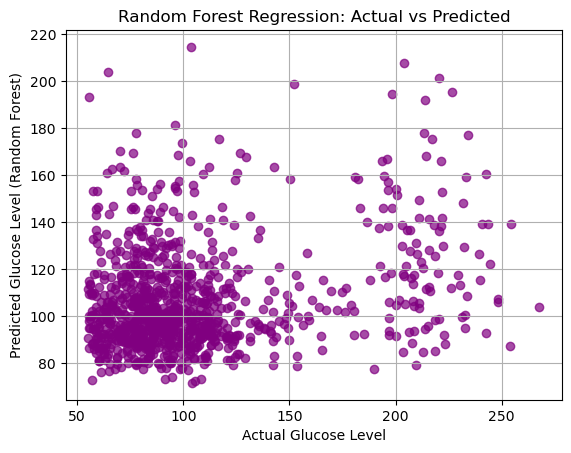

In [6]:
#comparing with random forest regression
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

# Visualize random forest regression prediction vs actual
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='purple')
plt.xlabel("Actual Glucose Level")
plt.ylabel("Predicted Glucose Level (Random Forest)")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.grid(True)

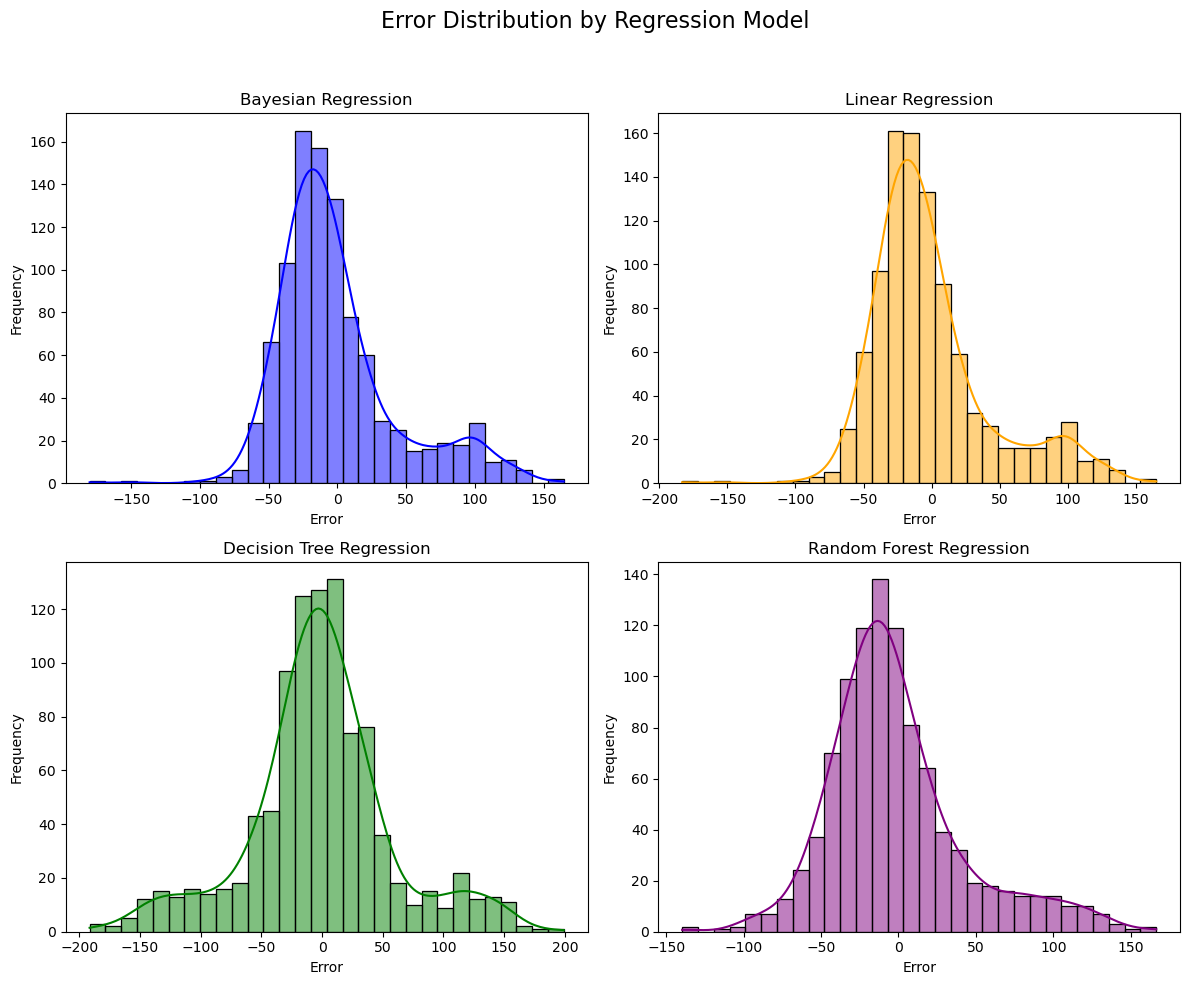

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate errors
errors_bayes = y_test - y_pred_bayes
errors_linear = y_test - y_pred_linear
errors_tree = y_test - y_pred_tree
errors_rf = y_test - y_pred_rf

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Error Distribution by Regression Model", fontsize=16)

# Bayesian
sns.histplot(errors_bayes, kde=True, color='blue', bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Bayesian Regression")
axes[0, 0].set_xlabel("Error")
axes[0, 0].set_ylabel("Frequency")

# Linear
sns.histplot(errors_linear, kde=True, color='orange', bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Linear Regression")
axes[0, 1].set_xlabel("Error")
axes[0, 1].set_ylabel("Frequency")

# Decision Tree
sns.histplot(errors_tree, kde=True, color='green', bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Decision Tree Regression")
axes[1, 0].set_xlabel("Error")
axes[1, 0].set_ylabel("Frequency")

# Random Forest
sns.histplot(errors_rf, kde=True, color='purple', bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Random Forest Regression")
axes[1, 1].set_xlabel("Error")
axes[1, 1].set_ylabel("Frequency")

# Improve layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
